In [1]:
import qiskit


## Week 2: Entanglement & Bell States

1. Theory: The "Spooky" Connection

In Week 1, we learned about single qubits. In Week 2, we learn how two qubits can become "entangled."

What is Entanglement?
It is a quantum phenomenon where two particles become linked such that the state of one particle instantly influences the state of the other, regardless of the distance between them.

The Bell States:
There are 4 specific two-qubit states that are "maximally entangled." We focus on the most famous one: $|\Phi^+\rangle$.

How to create it?

Superposition: Put Qubit 0 into a 50/50 state using an H-gate.

Correlation: Use a CNOT gate where Qubit 0 is the Control and Qubit 1 is the Target.

If Q0 is $|0\rangle$, Q1 stays $|0\rangle$.

If Q0 is $|1\rangle$, Q1 flips to $|1\rangle$.

Since Q0 is in superposition, both happen simultaneously!

2. Code: Creating the $|\Phi^+\rangle$ Bell State

Circuit for Bell State |Phi+>:


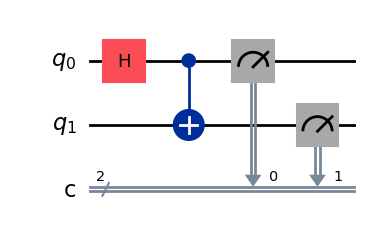


Measurement Results: {'00': 508, '11': 516}


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Create a circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# 2. Apply Hadamard to qubit 0 (Superposition)
qc.h(0)

# 3. Apply CNOT (Entangle q0 and q1)
qc.cx(0, 1)

# 4. Measure both qubits
qc.measure([0, 1], [0, 1])

# 5. Visualize the circuit
print("Circuit for Bell State |Phi+>:")
display(qc.draw('mpl'))

# 6. Run the simulation
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# 7. Results
print("\nMeasurement Results:", counts)
plot_histogram(counts)
plt.show()






Observation: You will notice that you only get 00 or 11. You will never see 01 or 10. This is the proof of entanglement!

3. Hands-on Exercises

Exercise 1: The Anti-Correlated State ($|\Psi^+\rangle$)

Goal: Create a state where the qubits are always opposite (if Q0 is 0, Q1 is 1).

Task: Modify the code above. Add an X-gate to Qubit 1 before the H and CNOT gates.

Expected Result: Histogram should show only 01 and 10.

Exercise 2: The Phase Flip ($|\Phi^-\rangle$)

Goal: Create the $|\Phi^-\rangle$ state: $\frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$.

Task: Add a Z-gate to Qubit 0 after the H-gate but before the CNOT.

Question: Does the measurement histogram look different from the first code? (Spoiler: The probabilities are the same, but the underlying "phase" has changed!)

Exercise 3: Three Qubit Entanglement (GHZ State)

Goal: Entangle 3 qubits so they are all the same ($|000\rangle + |111\rangle$).

Task: 1. Create a QuantumCircuit(3, 3).
2. H-gate on Q0.
3. CNOT with Q0 as control, Q1 as target.
4. CNOT with Q1 as control, Q2 as target.
5. Measure all and plot.